**EMPLOYEE ATTRITION PREDICTION WITH HR ANALYTICS**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score



import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/IBM_HR-Employee-Attrition.csv")
print("Dataset Loaded successfully\n")
print(df.head())

Mounted at /content/drive
Dataset Loaded successfully

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  Relationshi

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
print("\nDataset columns:")
print(df.columns)


Dataset columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

In [ ]:
df.drop(
    ["EmployeeCount",
     "EmployeeNumber",
     "Over18",
     "StandardHours"],
    axis=1,
    inplace=True
)

print("\nUnnecessary Columns Removed")


Unnecessary Columns Removed


In [ ]:
df = pd.get_dummies(
    df,
    drop_first=True
)

print("\nCategorical Columns Encoded")

df = df.astype(int)


Categorical Columns Encoded


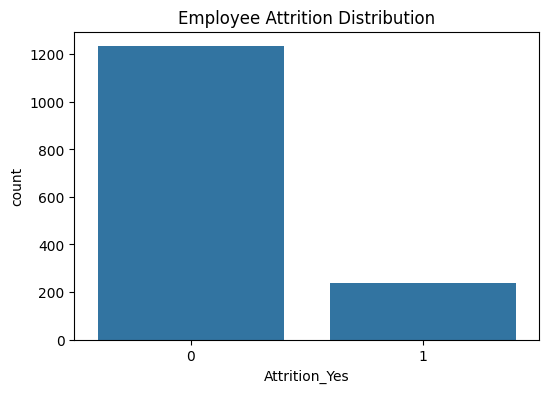

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Attrition_Yes', data=df)

plt.title("Employee Attrition Distribution")

plt.show()

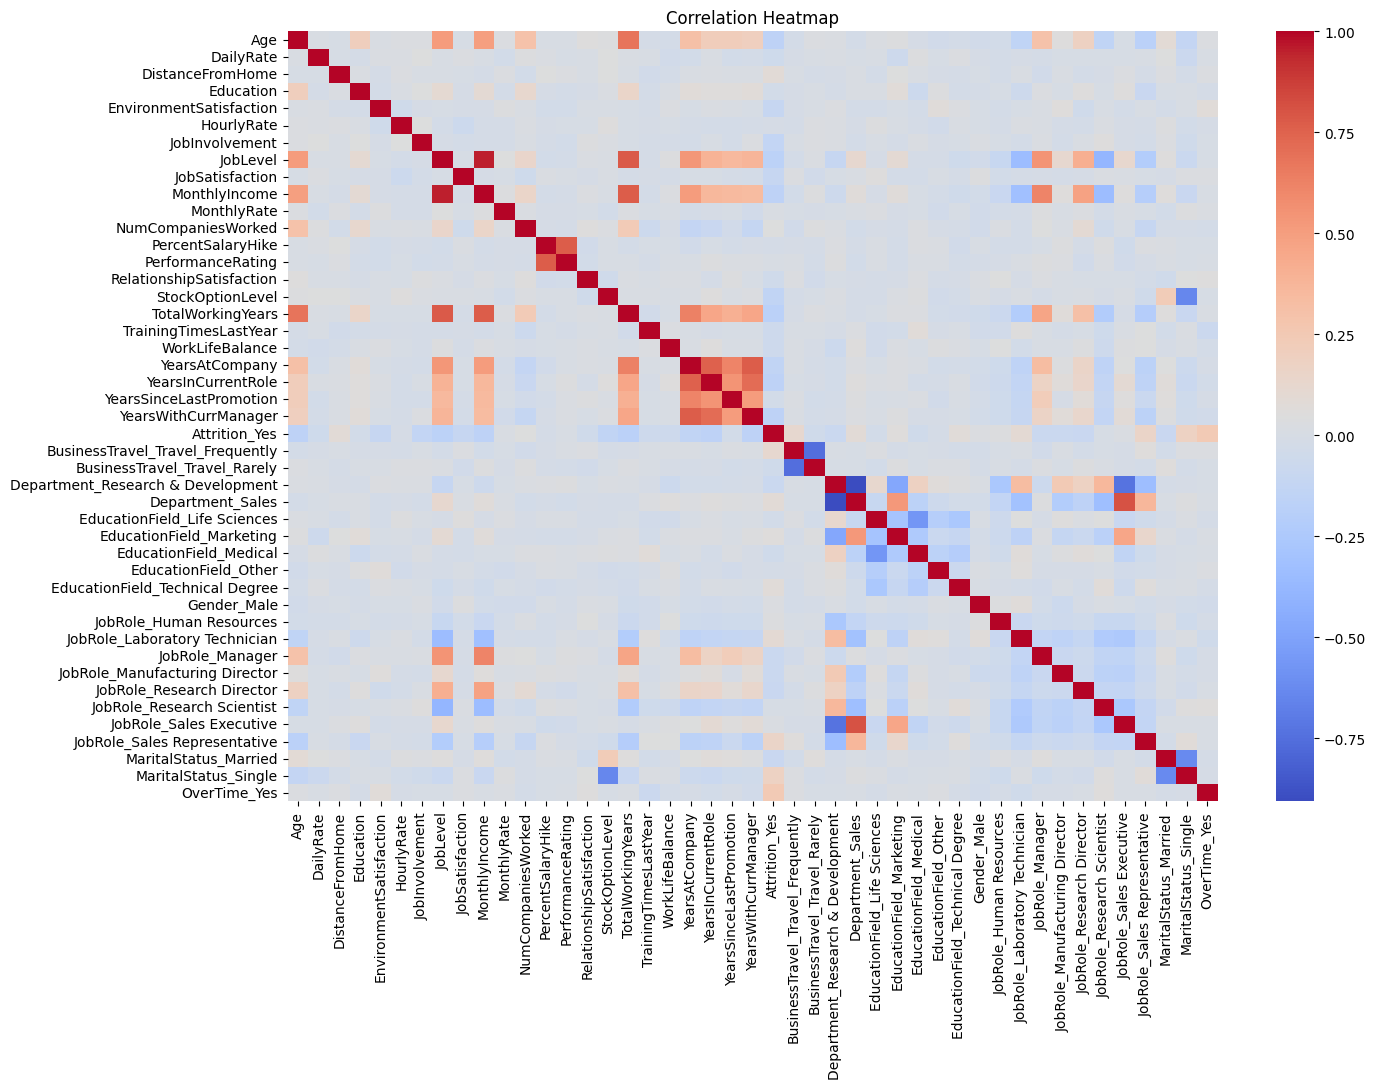

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain Test Split Completed")


Train Test Split Completed


In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

print("\nLogistic Regression Accuracy:", log_accuracy)


Logistic Regression Accuracy: 0.8809523809523809


In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\nDecision Tree Accuracy:")
print(dt_accuracy)


Decision Tree Accuracy:
0.8673469387755102


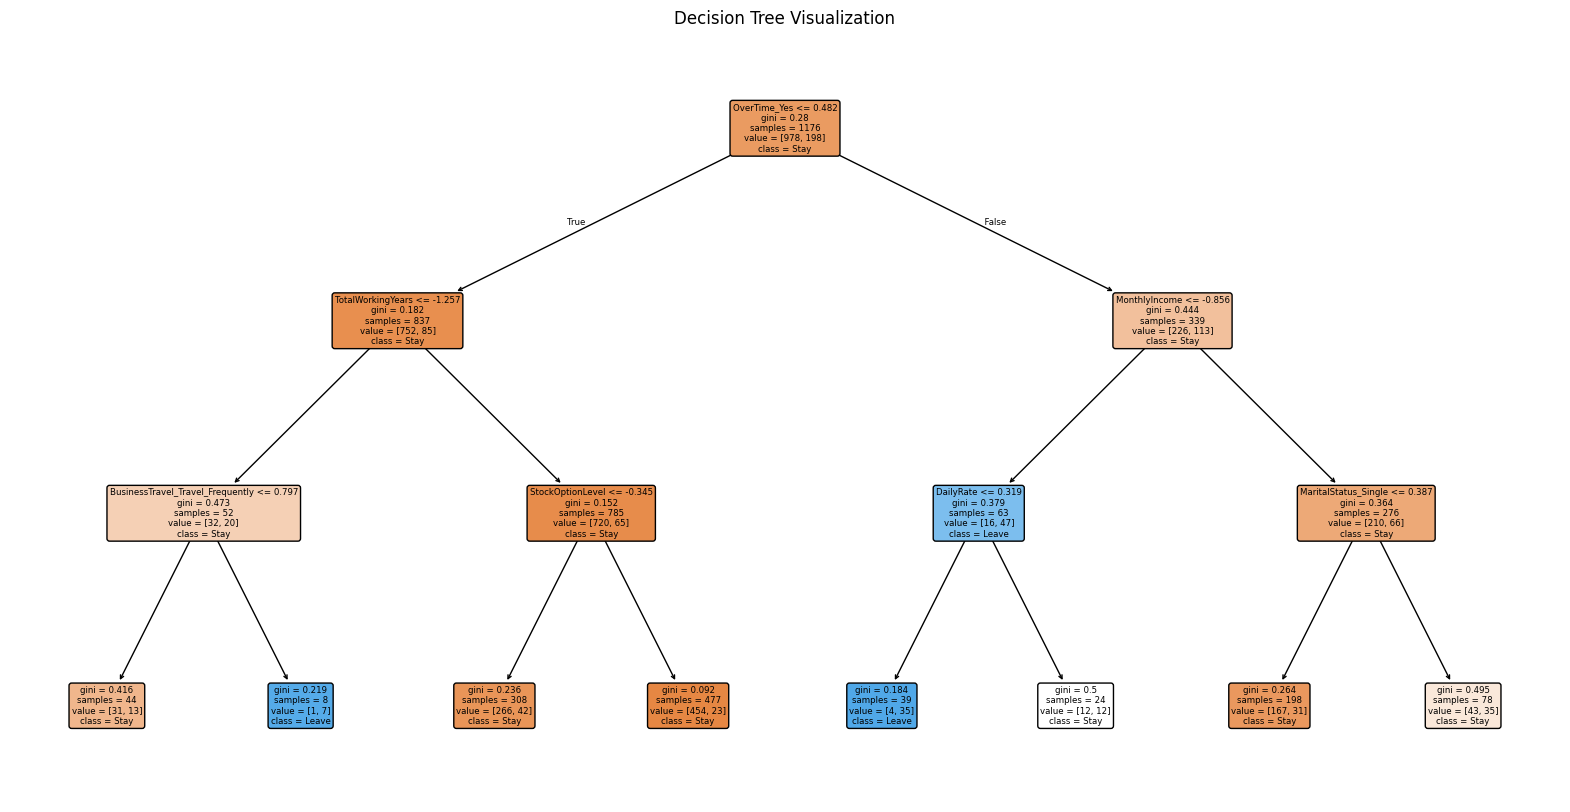

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=["Stay", "Leave"],
    rounded=True
)

plt.title("Decision Tree Visualization")

plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)


Random Forest Accuracy:
0.8775510204081632


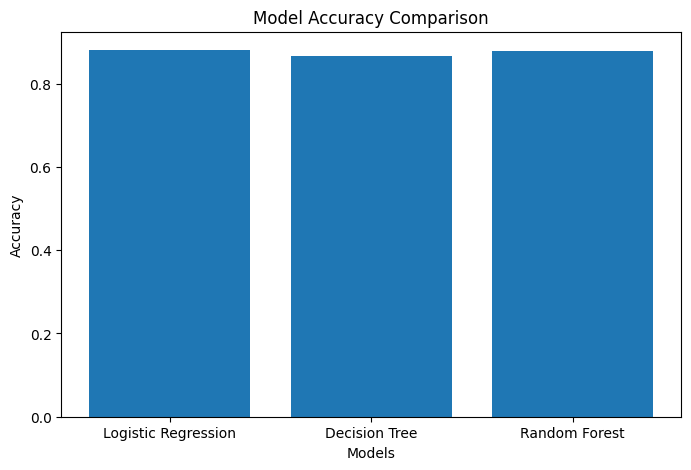

In [ ]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    log_accuracy,
    dt_accuracy,
    rf_accuracy
]


plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
cv_scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage Cross Validation Accuracy:")
print(cv_scores.mean())


Cross Validation Scores:
[0.85034014 0.85714286 0.86394558 0.8537415  0.86054422]

Average Cross Validation Accuracy:
0.8571428571428571



Confusion Matrix:
[[254   1]
 [ 35   4]]


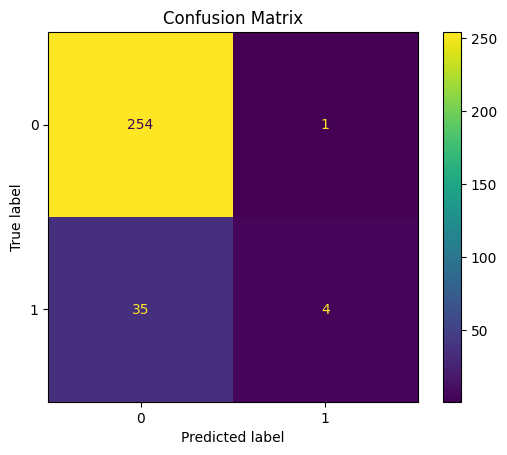

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294




AUC Score:
0.7526395173453997


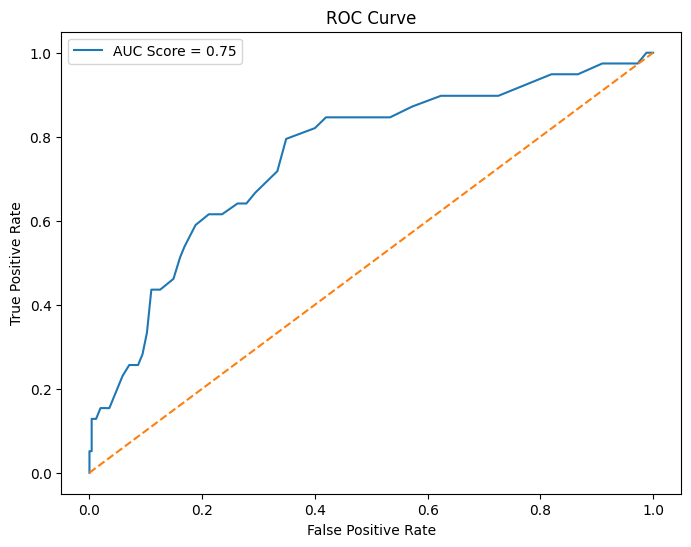

In [ ]:
# ROC Curve and AUC Score

rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

auc_score = roc_auc_score(y_test, rf_prob)

print("\nAUC Score:")
print(auc_score)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC Score = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
# feature importance

importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")

print(feature_df.head(15))


Top Important Features:

                    Feature  Importance
9             MonthlyIncome    0.079447
43             OverTime_Yes    0.058897
0                       Age    0.056085
1                 DailyRate    0.051504
10              MonthlyRate    0.048895
16        TotalWorkingYears    0.048578
2          DistanceFromHome    0.042809
5                HourlyRate    0.041754
19           YearsAtCompany    0.041551
11       NumCompaniesWorked    0.037947
15         StockOptionLevel    0.035863
12        PercentSalaryHike    0.035786
22     YearsWithCurrManager    0.031138
21  YearsSinceLastPromotion    0.028314
8           JobSatisfaction    0.027273


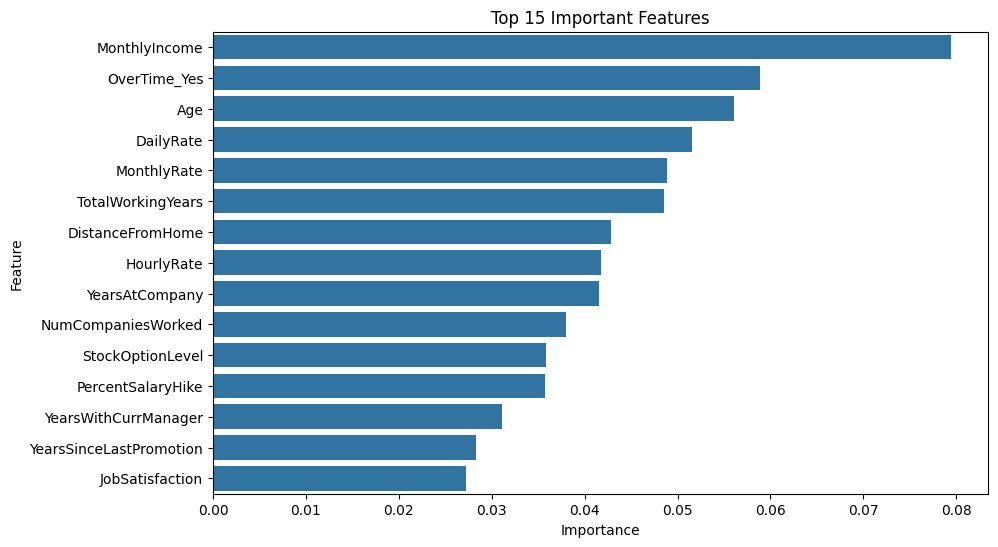

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
sample_employee = X.iloc[0:1]

print("\nSample Employee Data:")
print(sample_employee)

sample_employee_scaled = scaler.transform(sample_employee)

prediction = rf_model.predict(sample_employee_scaled)

print("------------------------------------")
print("Sample Employee Attrition Prediction ")
print("------------------------------------")


if prediction[0] == 1:
    print("\nPrediction Result: Employee Likely to Leave")
else:
    print("\nPrediction Result: Employee Likely to Stay")



Sample Employee Data:
   Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   41       1102                 1          2                        2   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          94               3         2                4           5993  ...   

   JobRole_Laboratory Technician  JobRole_Manager  \
0                              0                0   

   JobRole_Manufacturing Director  JobRole_Research Director  \
0                               0                          0   

   JobRole_Research Scientist  JobRole_Sales Executive  \
0                           0                        1   

   JobRole_Sales Representative  MaritalStatus_Married  MaritalStatus_Single  \
0                             0                      0                     1   

   OverTime_Yes  
0             1  

[1 rows x 44 columns]
------------------------------------
Sample Employee Attrition Prediction 
-----------------